# Lesson 5: Evoked and induced activity

Neurocampus course "Signals of the whole brain"

Daria Kleeva

dkleeva@gmail.com

March 25, 2026


## Import the data

In [3]:
import mne
import numpy as np
from matplotlib import pyplot as plt
folder_name = '/Users/dkleeva/Library/CloudStorage/GoogleDrive-dkleeva@gmail.com/My Drive/Teaching/Сигналы целого мозга 2026/Scripts/Data/EEG/'
raw = mne.io.read_raw_edf(folder_name + 'sounds.edf',preload=True)
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)
raw.filter(0.1, 40)

Extracting EDF parameters from /Users/dkleeva/Library/CloudStorage/GoogleDrive-dkleeva@gmail.com/My Drive/Teaching/Сигналы целого мозга 2026/Scripts/Data/EEG/sounds.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 331999  =      0.000 ...   331.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    0.2s finished


<RawEDF | sounds.edf, 38 x 332000 (332.0 s), ~96.3 MB, data loaded>

Using matplotlib as 2D backend.


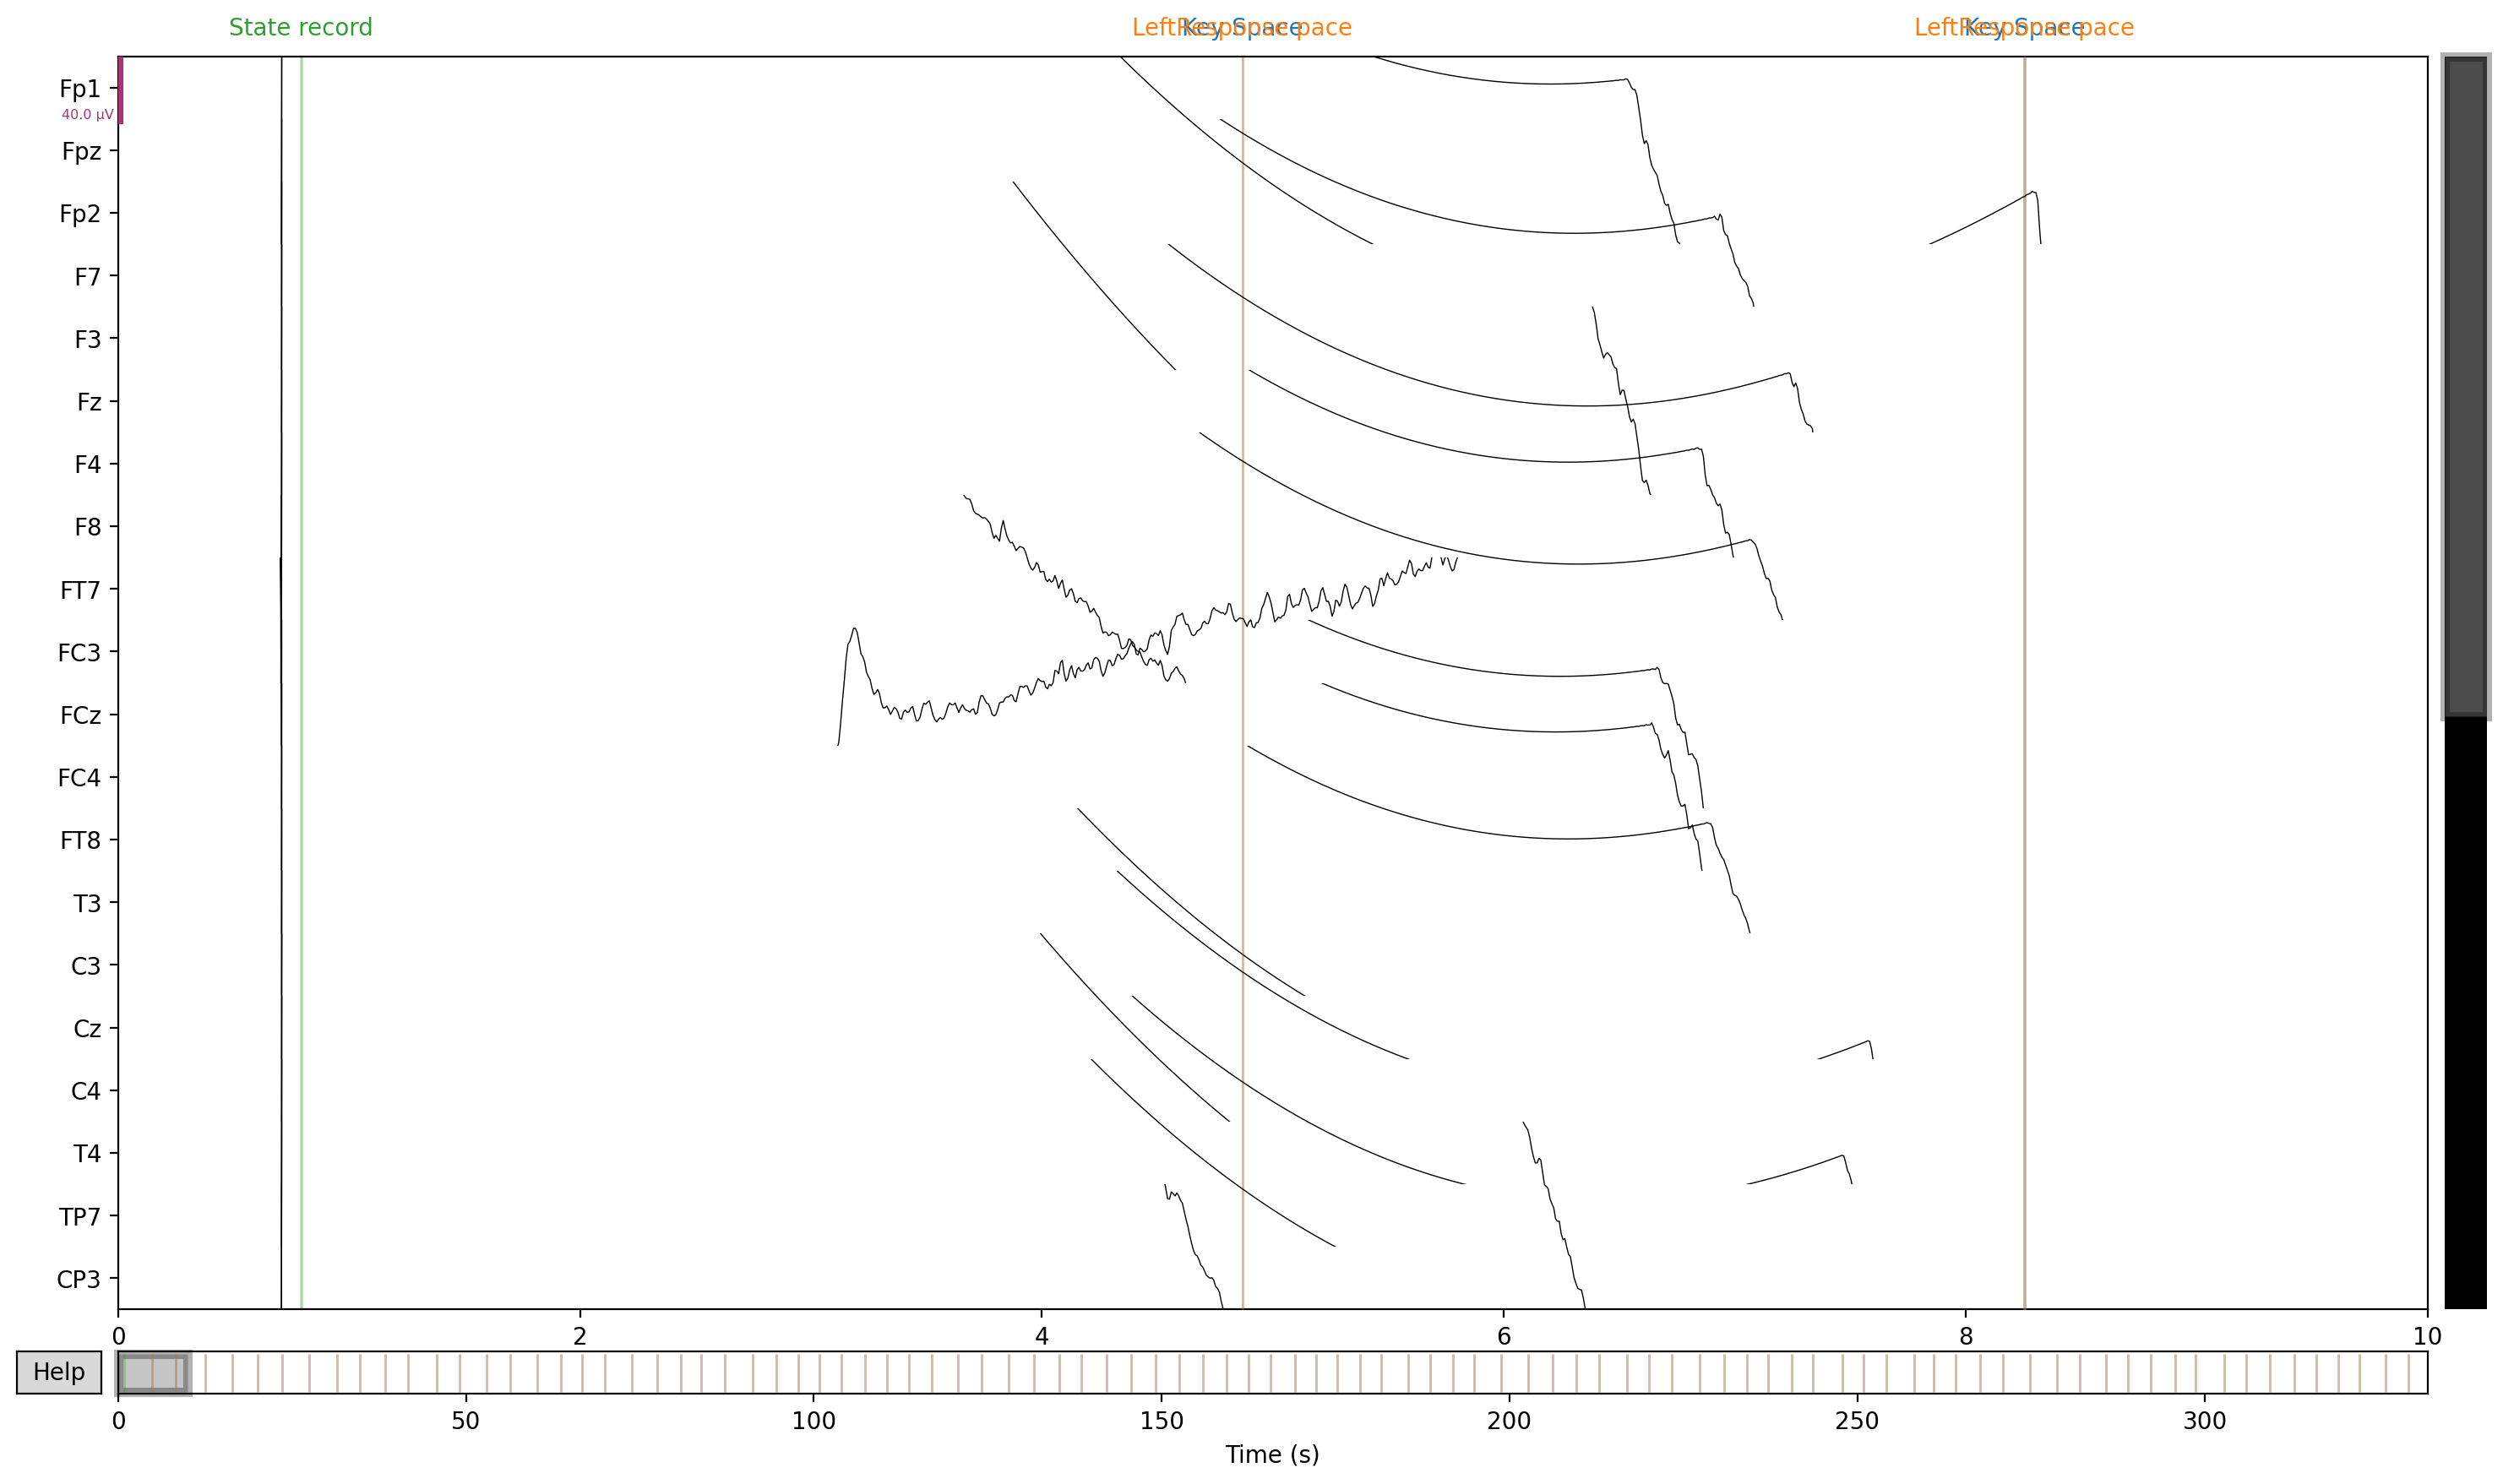

Channels marked as bad:
none


In [2]:
%matplotlib qt
raw.plot()

## Events and epochs

In [4]:
# events = mne.find_events(ra, stim_channel="STI 014")
events, event_id = mne.events_from_annotations(raw)
print(events)
print(event_id)

Used Annotations descriptions: [np.str_('Key Space'), np.str_('LeftResponse pace'), np.str_('State record')]
[[   791      0      3]
 [  4868      0      1]
 [  4868      0      2]
 [  8254      0      1]
 [  8254      0      2]
 [ 12499      0      1]
 [ 12499      0      2]
 [ 16382      0      1]
 [ 16382      0      2]
 [ 20016      0      1]
 [ 20016      0      2]
 [ 23560      0      1]
 [ 23560      0      2]
 [ 27478      0      1]
 [ 27478      0      2]
 [ 31395      0      1]
 [ 31395      0      2]
 [ 34739      0      1]
 [ 34739      0      2]
 [ 38410      0      1]
 [ 38410      0      2]
 [ 41629      0      1]
 [ 41629      0      2]
 [ 45832      0      1]
 [ 45832      0      2]
 [ 49097      0      1]
 [ 49097      0      2]
 [ 52920      0      1]
 [ 52920      0      2]
 [ 56353      0      1]
 [ 56353      0      2]
 [ 60268      0      1]
 [ 60268      0      2]
 [ 63614      0      1]
 [ 63614      0      2]
 [ 66679      0      1]
 [ 66679      0      2]
 [ 

The first column contains the event onset (in samples) **with first_samp included**. The last column contains the event code. The second column contains the signal value of the immediately preceding sample, and reflects the fact that event arrays sometimes originate from analog voltage channels (“trigger channels” or “stim channels”). In most cases, the second column is all zeros and can be ignored.

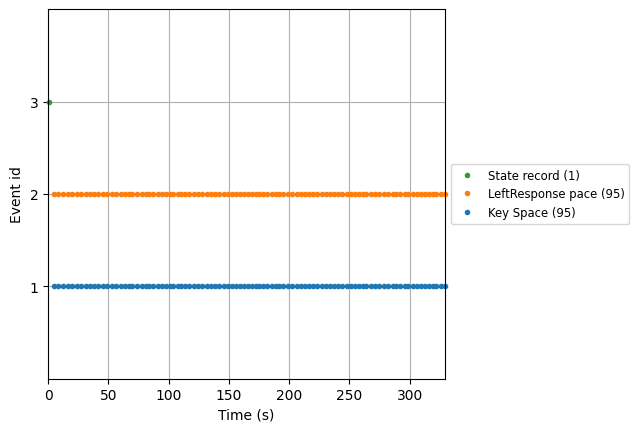

In [5]:
%matplotlib inline
fig = mne.viz.plot_events(
    events, sfreq=raw.info["sfreq"], first_samp=raw.first_samp, event_id=event_id)

In [6]:
events = events[events[:, 2] == event_id[np.str_('Key Space')]]
print(events)


[[  4868      0      1]
 [  8254      0      1]
 [ 12499      0      1]
 [ 16382      0      1]
 [ 20016      0      1]
 [ 23560      0      1]
 [ 27478      0      1]
 [ 31395      0      1]
 [ 34739      0      1]
 [ 38410      0      1]
 [ 41629      0      1]
 [ 45832      0      1]
 [ 49097      0      1]
 [ 52920      0      1]
 [ 56353      0      1]
 [ 60268      0      1]
 [ 63614      0      1]
 [ 66679      0      1]
 [ 69901      0      1]
 [ 73861      0      1]
 [ 77527      0      1]
 [ 80907      0      1]
 [ 83807      0      1]
 [ 87241      0      1]
 [ 91240      0      1]
 [ 94585      0      1]
 [ 97760      0      1]
 [100769      0      1]
 [103988      0      1]
 [107322      0      1]
 [110504      0      1]
 [113642      0      1]
 [116903      0      1]
 [120660      0      1]
 [124165      0      1]
 [127958      0      1]
 [131590      0      1]
 [135260      0      1]
 [138484      0      1]
 [142033      0      1]
 [145581      0      1]
 [149175      0 

## Epochs

In [8]:
epochs_long = mne.Epochs(raw, events, tmin=-0.5, tmax=0.7, baseline=(-0.1, 0), event_id={'Sound':1}, preload=True)
epochs=epochs_long.copy().crop(-0.1,0.7)

Not setting metadata
95 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 95 events and 1201 original time points ...
0 bad epochs dropped


In [9]:
epochs

<Epochs | 95 events (all good), -0.1 – 0.7 s (baseline -0.1 – 0 s), ~22.1 MB, data loaded,
 'Sound': 95>

In [10]:
epochs.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, F7, F3, Fz, F4, F8, FT7, FC3, FCz, FC4, FT8, T3, ...
 chs: 38 EEG
 custom_ref_applied: False
 dig: 41 items (3 Cardinal, 38 EEG)
 highpass: 0.1 Hz
 lowpass: 40.0 Hz
 meas_date: 2026-03-04 12:17:54 UTC
 nchan: 38
 projs: []
 sfreq: 1000.0 Hz
 subject_info: 4 items (dict)
>

In [11]:
print(epochs.drop_log)

((), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ())


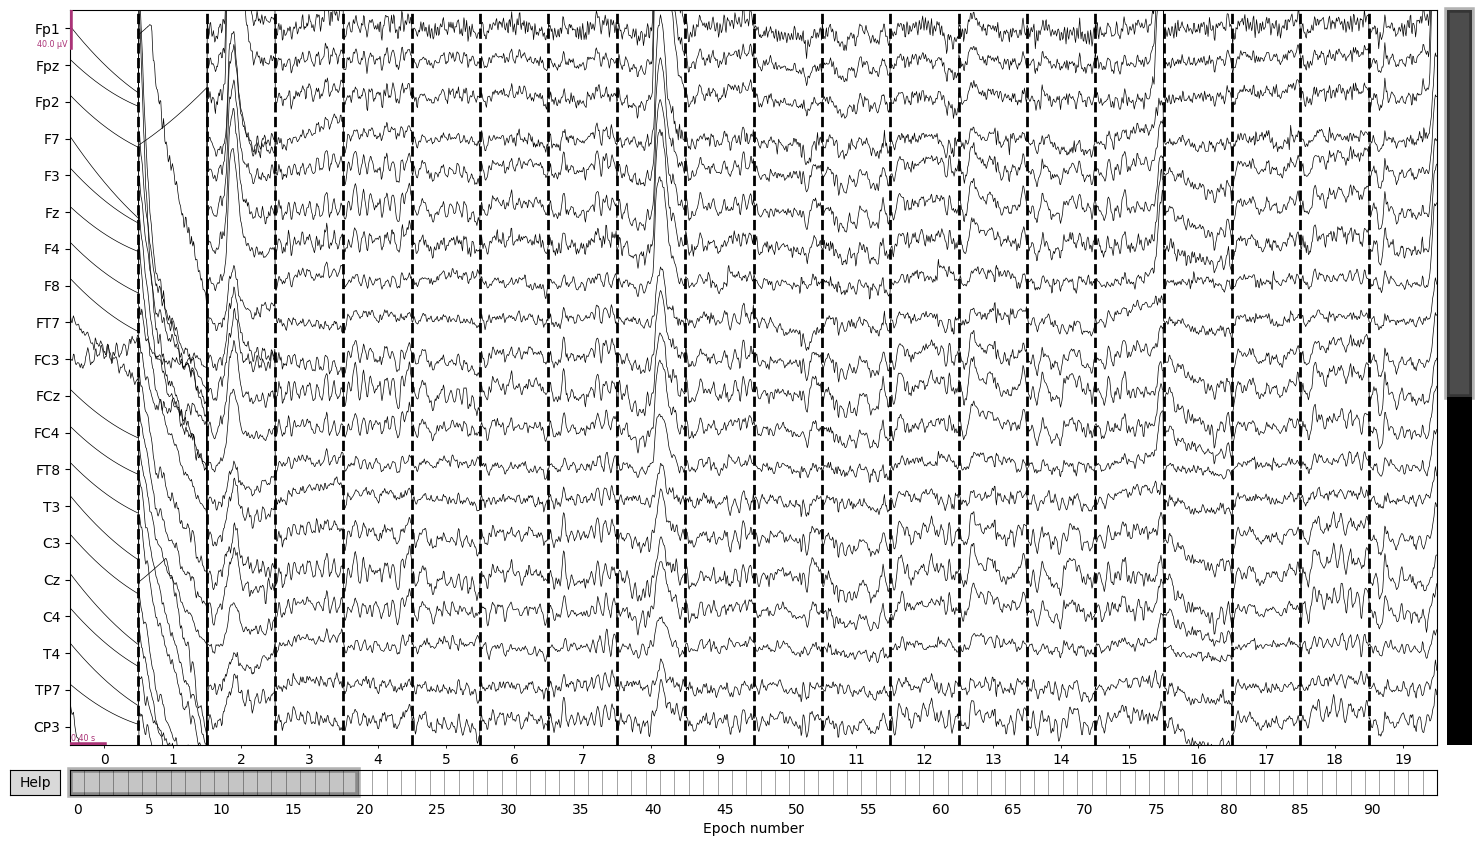

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [ ]:
%matplotlib qt
epochs.plot()

In [12]:
#remove bad epochs based on the rejection parameters
reject = dict(eeg=100e-6)
epochs.drop_bad(reject=reject)

print(epochs.drop_log)

    Rejecting  epoch based on EEG : ['CP3', 'T6', 'P5', 'P6', 'PO7', 'O1']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4', 'F8', 'FCz', 'FC4', 'FT8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP7', 'CPz', 'CP4', 'T5', 'P3', 'Pz', 'P4', 'PO3', 'POz', 'O2', 'PO8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FCz', 'FC4']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC4']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'F4']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8']
    Rejecting  epoch based on E

In [13]:
#Let's return to the original epochs
epochs = mne.Epochs(raw, events, tmin=-0.1, tmax=0.7, baseline=(-0.1, 0), event_id={'Sound':1}, preload=True)

Not setting metadata
95 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 95 events and 801 original time points ...
0 bad epochs dropped


## Clean the data

Fitting ICA to data using 38 channels (please be patient, this may take a while)
Selecting by explained variance: 4 components


/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_32793/3837345770.py:3: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(epochs)


Fitting ICA took 0.3s.
Not setting metadata
95 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


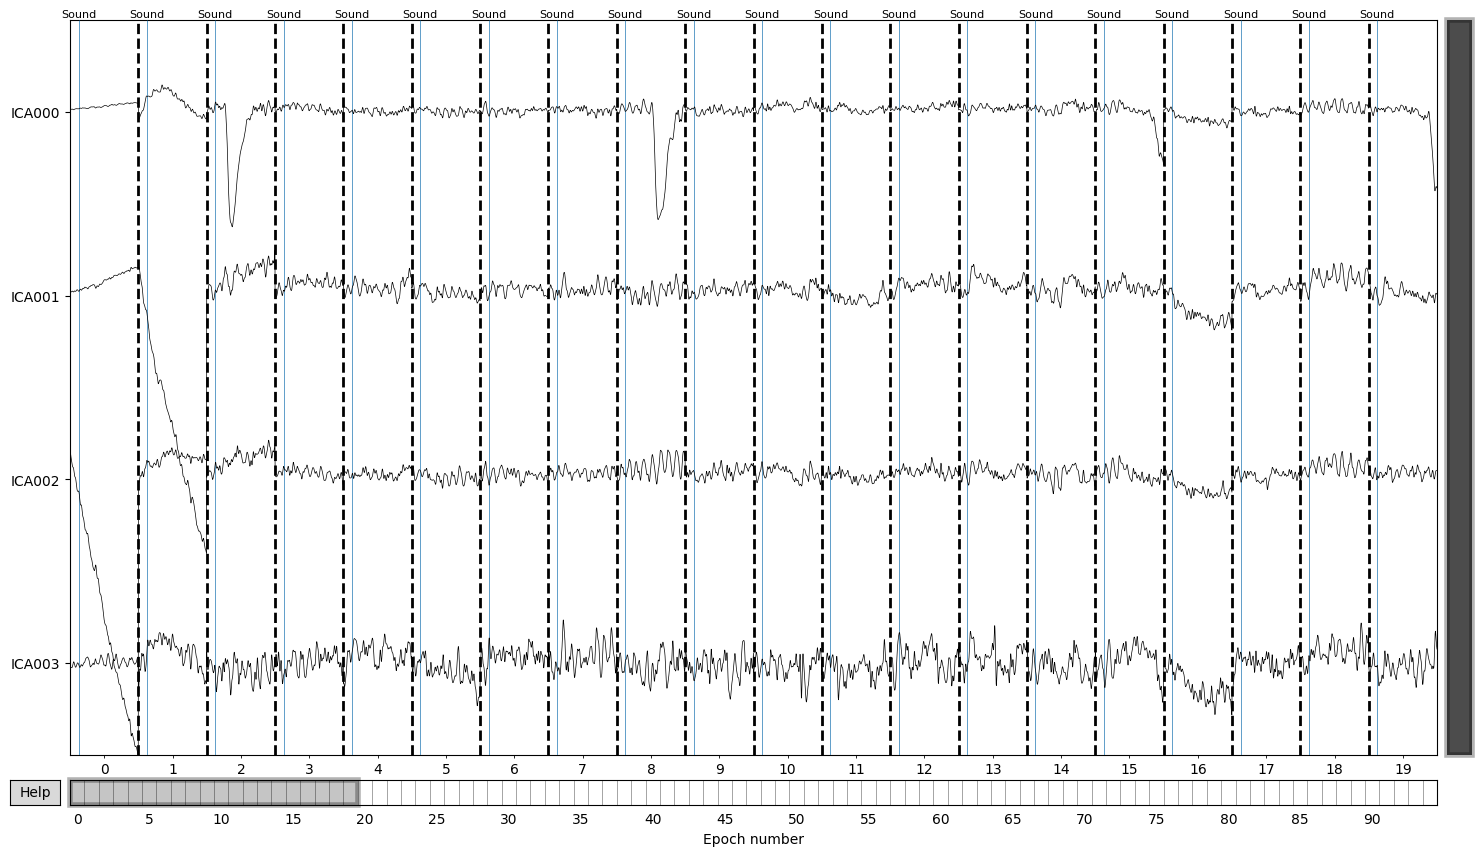

In [14]:
%matplotlib qt
ica = mne.preprocessing.ICA(n_components=0.95, max_iter='auto', random_state=97)
ica.fit(epochs)
ica.plot_sources(epochs)


    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
95 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
95 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
95 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
95 matching events found
No baseline correction applied
0 projection items activated


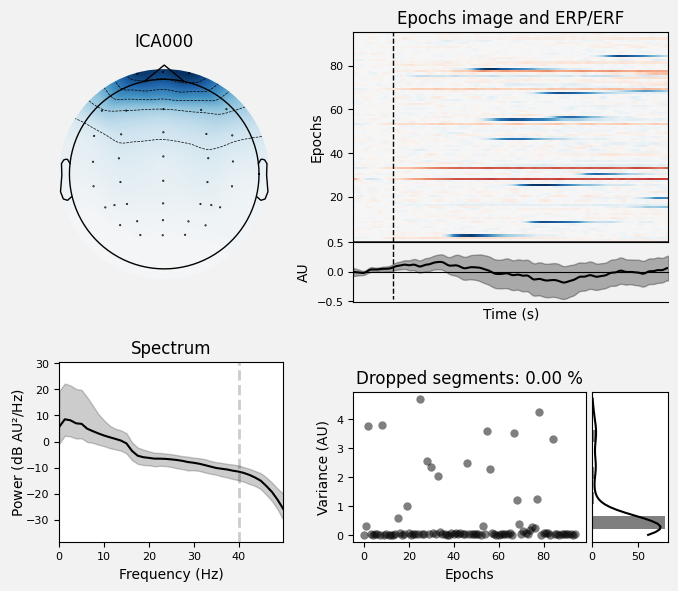

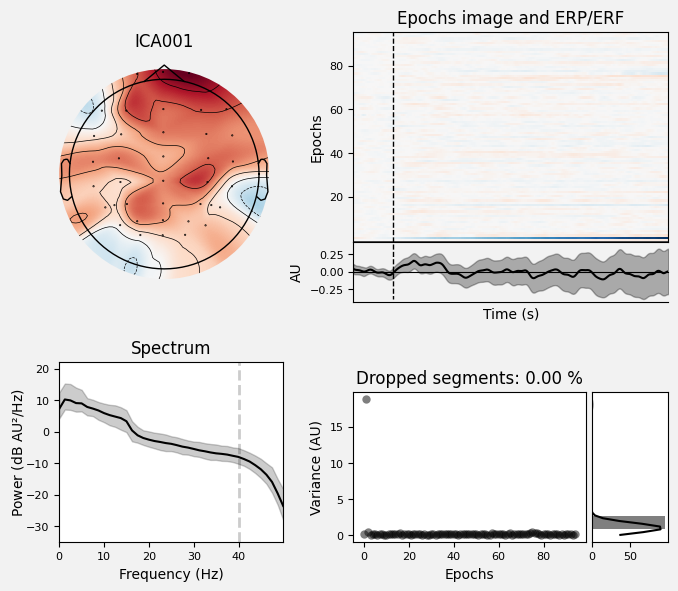

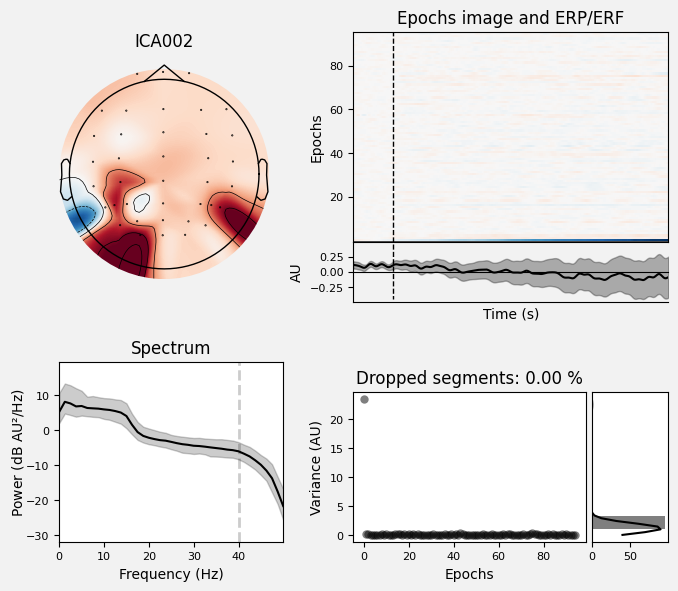

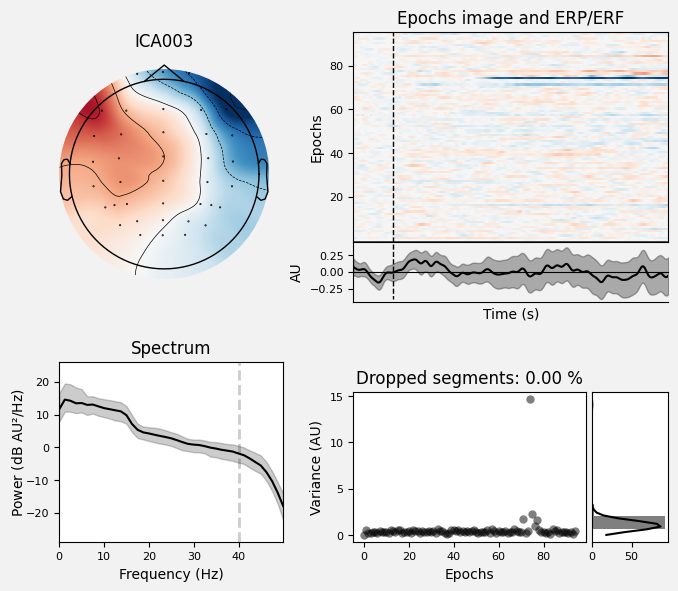

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [14]:
%matplotlib inline
ica.plot_properties(epochs, picks=[0, 1, 2, 3])

In [15]:
ica.exclude=[0]
ica.apply(epochs)
ica.apply(epochs_long)

Applying ICA to Epochs instance
    Transforming to ICA space (4 components)
    Zeroing out 1 ICA component
    Projecting back using 38 PCA components
Applying ICA to Epochs instance
    Transforming to ICA space (4 components)
    Zeroing out 1 ICA component
    Projecting back using 38 PCA components


/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_32793/3274990023.py:2: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please note that ICA can introduce DC shifts, therefore you may wish to consider baseline-correcting the cleaned data again.
  ica.apply(epochs)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: divide by zero encountered in matmul
  mixing = pca_components.T @ mixing
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: overflow encountered in matmul
  mixing = pca_components.T @ mixing
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/preprocessing/ica.py:2370: RuntimeWarning: invalid value encountered in matmul
  mixing = pca_components.T @ mixing
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_32793/3274990023.py:3: RuntimeWarning: The data you passed to ICA.apply() was baseline-corrected. Please n

<Epochs | 95 events (all good), -0.5 – 0.7 s (baseline -0.1 – 0 s), ~33.1 MB, data loaded,
 'Sound': 95>

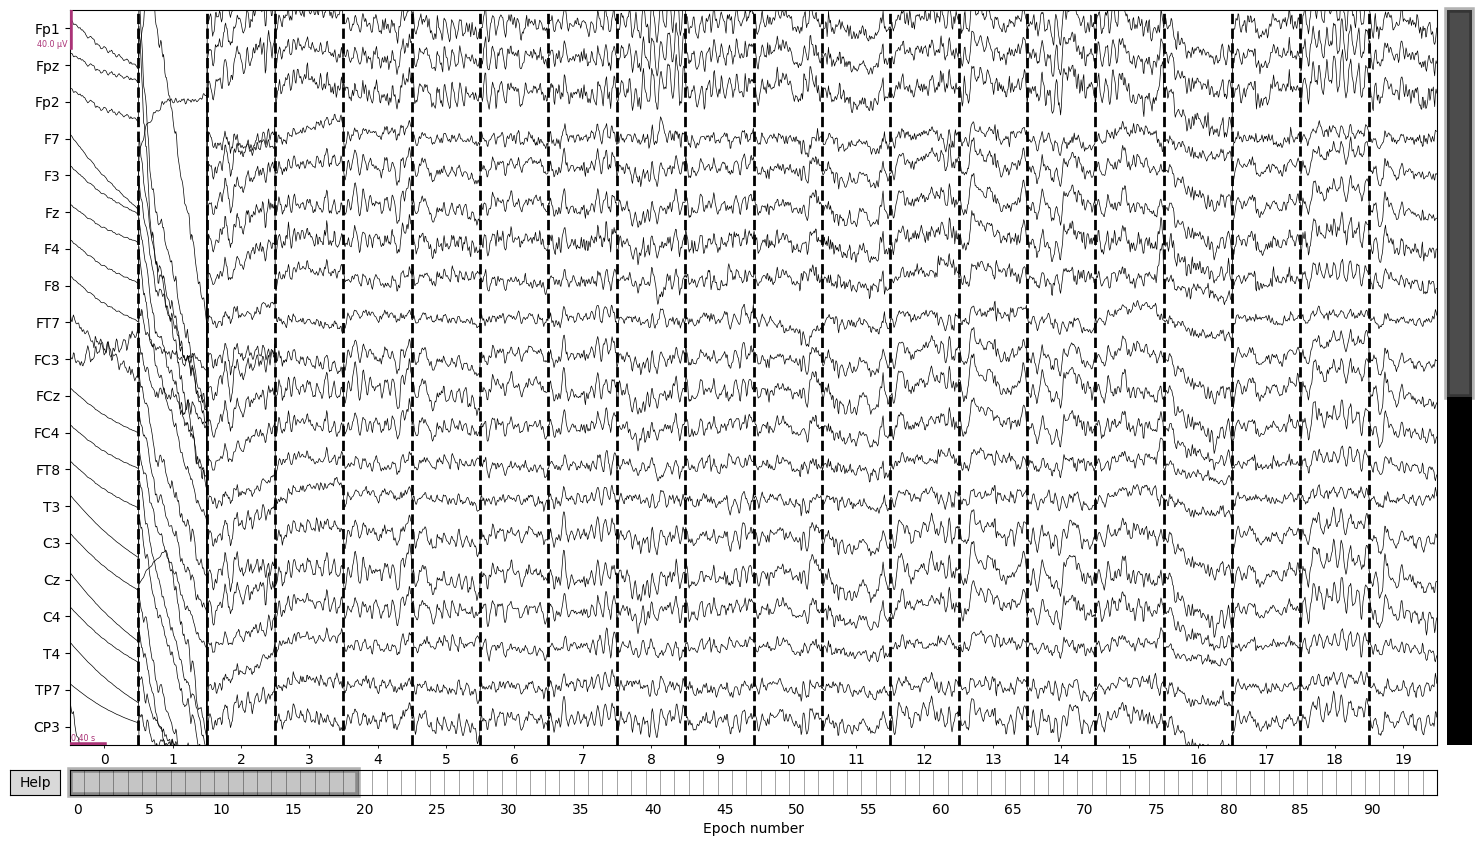

In [16]:
epochs.plot()
plt.show()

In [16]:
#remove bad epochs based on the rejection parameters
reject = dict(eeg=100e-6)
epochs.drop_bad(reject=reject)

print(epochs.drop_log)

    Rejecting  epoch based on EEG : ['CP3', 'T6', 'P5', 'P6', 'PO7', 'O1']
    Rejecting  epoch based on EEG : ['Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4', 'F8', 'FCz', 'FC4', 'FT8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP7', 'CPz', 'CP4', 'T5', 'P3', 'Pz', 'P4', 'PO3', 'POz', 'O2', 'PO8']
    Rejecting  epoch based on EEG : ['FC3', 'FC4', 'T3', 'C3', 'T4', 'TP7', 'CP3', 'P5']
    Rejecting  epoch based on EEG : ['Fpz', 'Fp2', 'F8']
    Rejecting  epoch based on EEG : ['Fp2']
    Rejecting  epoch based on EEG : ['Fp2']
6 bad epochs dropped
(('CP3', 'T6', 'P5', 'P6', 'PO7', 'O1'), ('Fp1', 'Fpz', 'Fp2', 'F3', 'Fz', 'F4', 'F8', 'FCz', 'FC4', 'FT8', 'T3', 'C3', 'Cz', 'C4', 'T4', 'TP7', 'CPz', 'CP4', 'T5', 'P3', 'Pz', 'P4', 'PO3', 'POz', 'O2', 'PO8'), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), (), ('FC3', 'FC4', 'T3', 'C3', 'T4', '

## ERP

Not setting metadata
89 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


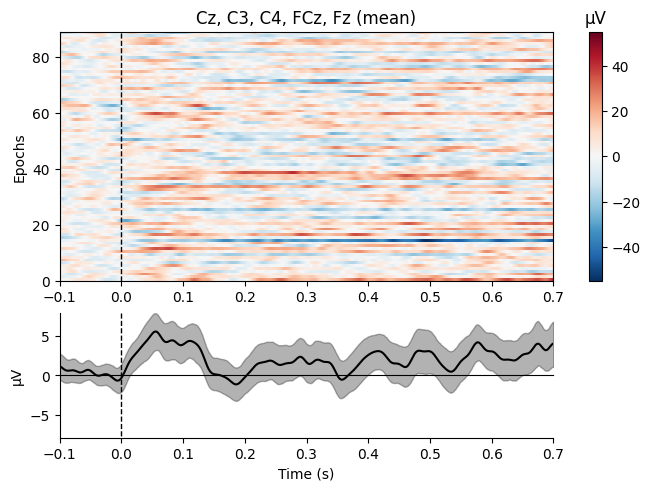

In [18]:
%matplotlib inline
epochs.plot_image(combine="mean", picks=['Cz', 'C3', 'C4', 'FCz', 'Fz'])
plt.show()

In [19]:
evoked = epochs.average()

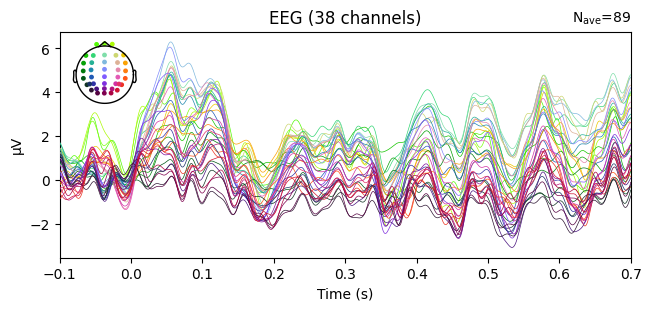

In [20]:
%matplotlib qt
evoked.plot()

No projector specified for this dataset. Please consider the method self.add_proj.


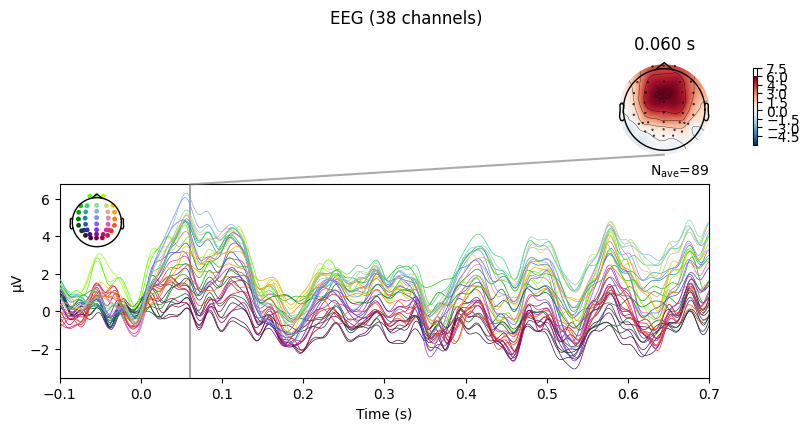

In [21]:
epochs.average().plot_joint([0.06])

No projector specified for this dataset. Please consider the method self.add_proj.


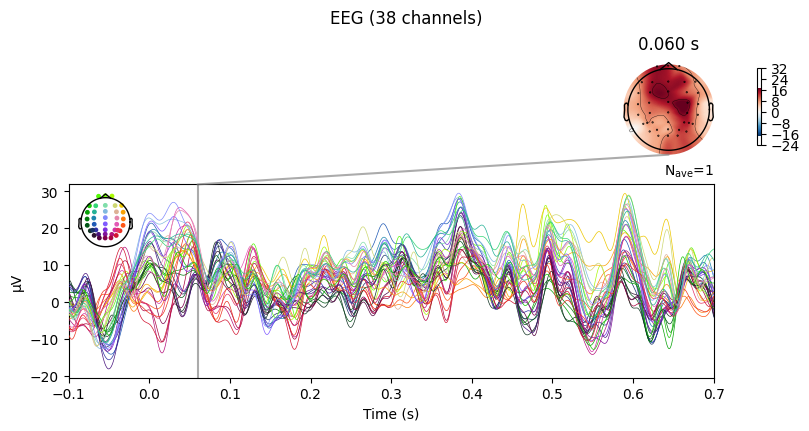

In [22]:
epochs[10].average().plot_joint([0.06])

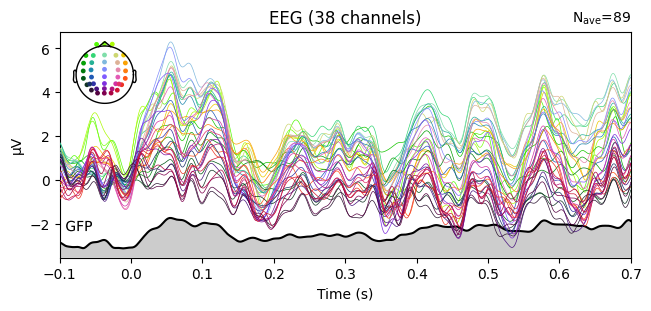

In [23]:
%matplotlib inline
evoked.plot(spatial_colors=True, gfp=True)
plt.show()

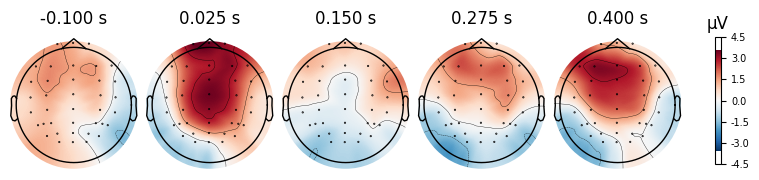

In [24]:
evoked.plot_topomap(times=np.linspace(-0.1, 0.4, 5), colorbar=True)
plt.show()

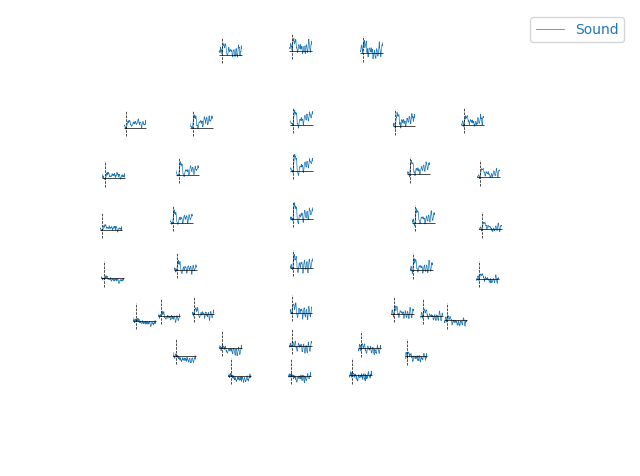

In [25]:
%matplotlib qt
mne.viz.plot_evoked_topo(evoked)

In [26]:
subjects_dir = '/Users/dkleeva/mne_data/MNE-fsaverage-data/'
maps = mne.make_field_map(
    evoked,
    trans='fsaverage',
    subject="fsaverage",
    subjects_dir=subjects_dir,
    origin="auto",
)
evoked.plot_field(maps, time=0.1)

Using surface from /Users/dkleeva/mne_data/MNE-fsaverage-data/fsaverage/bem/fsaverage-5120-5120-5120-bem.fif.
    Automatic origin fit: head of radius 94.9 mm
Prepare EEG mapping...
Computing dot products for 38 electrodes...
Computing dot products for 2562 surface locations...
Field mapping data ready
    Preparing the mapping matrix...
    Truncating at 22/38 components to omit less than 0.001 (0.00089)


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_field_interpolation.py:103: RuntimeWarning: divide by zero encountered in matmul
  inv = ((u[:, :n] * s) @ v[:n]).T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_field_interpolation.py:103: RuntimeWarning: overflow encountered in matmul
  inv = ((u[:, :n] * s) @ v[:n]).T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_field_interpolation.py:103: RuntimeWarning: invalid value encountered in matmul
  inv = ((u[:, :n] * s) @ v[:n]).T
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_field_interpolation.py:74: RuntimeWarning: divide by zero encountered in matmul
  inv_whitened_proj = proj_op.T @ inv_whitened
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/forward/_field_interpolation.py:74: Runti

Using pyvistaqt 3d backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/viz/evoked_field.py:269: RuntimeWarning: divide by zero encountered in matmul
  data = surf_map["data"] @ self._evoked.data[pick]
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/viz/evoked_field.py:269: RuntimeWarning: overflow encountered in matmul
  data = surf_map["data"] @ self._evoked.data[pick]
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/mne/viz/evoked_field.py:269: RuntimeWarning: invalid value encountered in matmul
  data = surf_map["data"] @ self._evoked.data[pick]


## Change the reference 

In [17]:
epochs.set_eeg_reference('average')
epochs_long.set_eeg_reference('average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<Epochs | 95 events (all good), -0.5 – 0.7 s (baseline -0.1 – 0 s), ~33.1 MB, data loaded,
 'Sound': 95>

No projector specified for this dataset. Please consider the method self.add_proj.


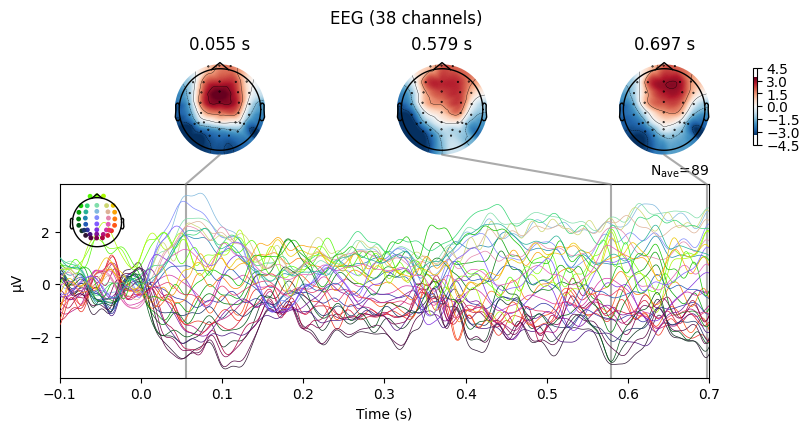

In [18]:
%matplotlib inline
evoked=epochs.average()
evoked.plot_joint()
plt.show()


Not setting metadata
89 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


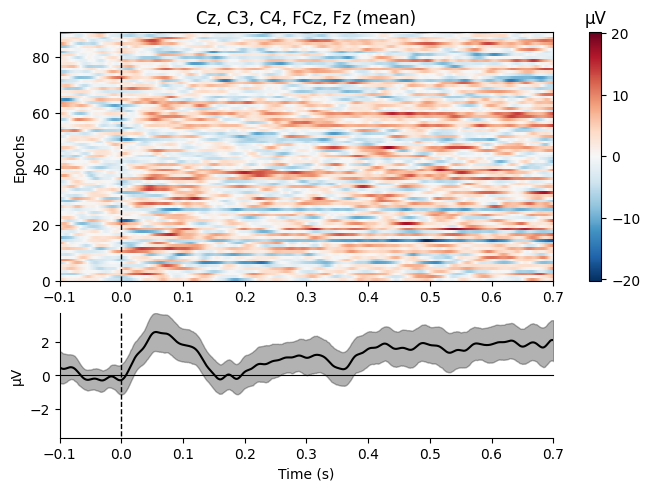

In [29]:
epochs.plot_image(combine="mean", picks=['Cz', 'C3', 'C4', 'FCz', 'Fz'])
plt.show()

Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


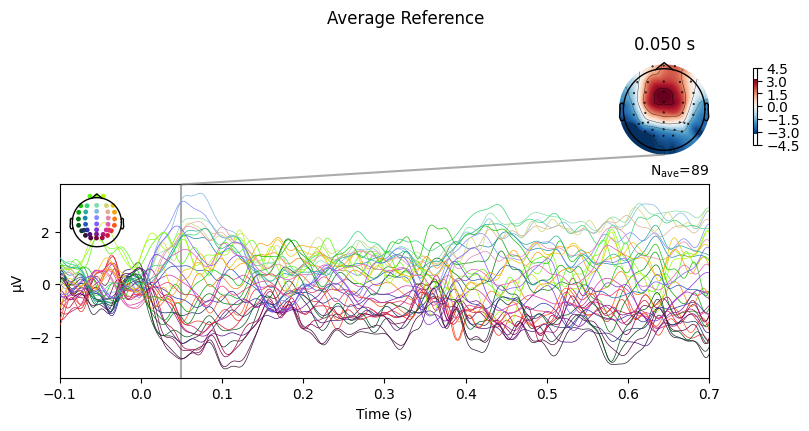

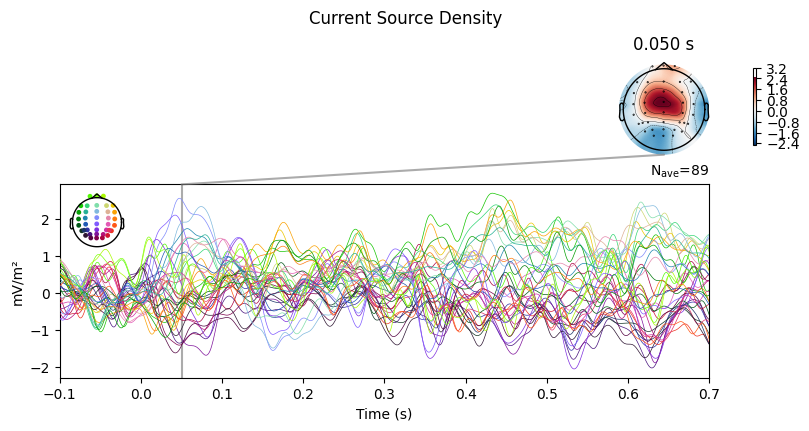

In [30]:
evoked_csd = mne.preprocessing.compute_current_source_density(evoked)
evoked.plot_joint([0.05], title="Average Reference", show=False)
evoked_csd.plot_joint([0.05], title="Current Source Density")
plt.show()

Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:      -1.1 14.6 45.8 mm
Origin device coordinates:    -1.1 14.6 45.8 mm
Fitted sphere radius:         94.9 mm
Origin head coordinates:

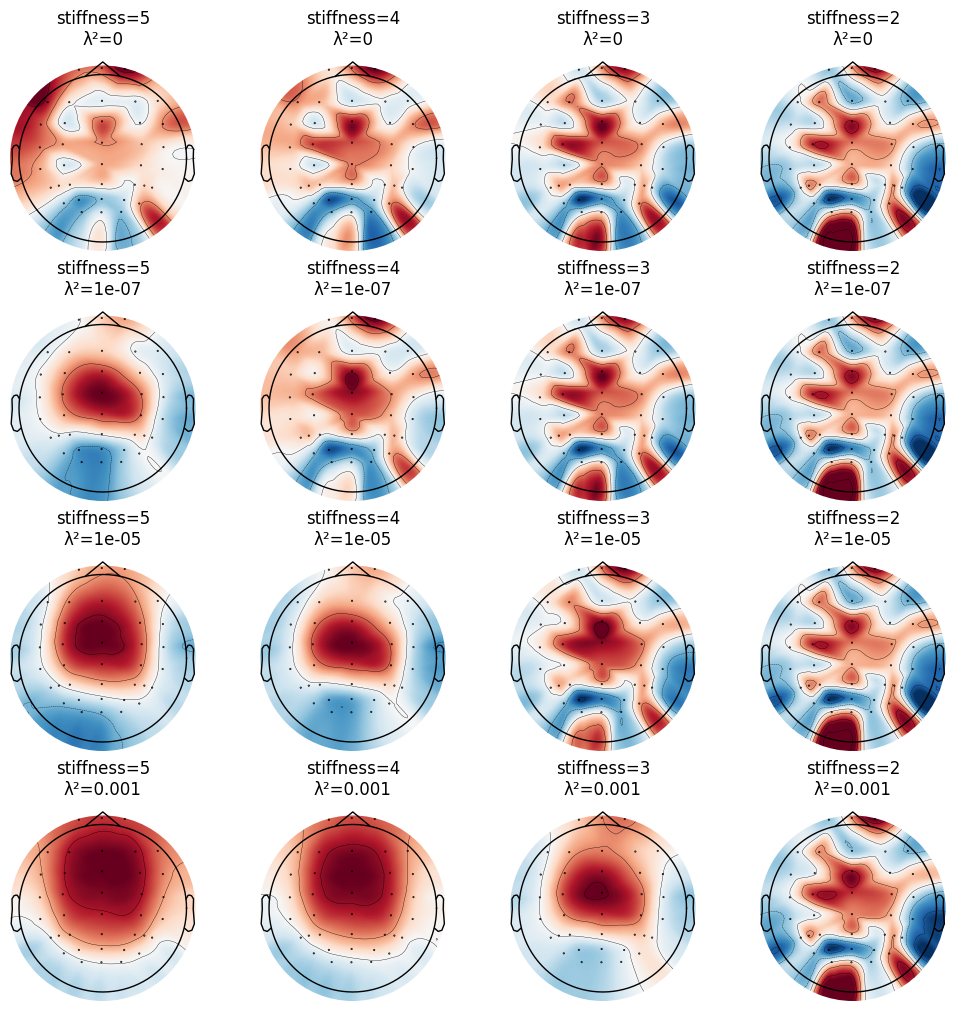

In [31]:
fig, ax = plt.subplots(4, 4, layout="constrained")
fig.set_size_inches(10, 10)
for i, lambda2 in enumerate([0, 1e-7, 1e-5, 1e-3]):
    for j, m in enumerate([5, 4, 3, 2]):
        this_evoked_csd = mne.preprocessing.compute_current_source_density(
            evoked, stiffness=m, lambda2=lambda2
        )
        this_evoked_csd.plot_topomap(
            0.05, axes=ax[i, j], contours=4, time_unit="s", colorbar=False, show=False
        )
        ax[i, j].set_title(f"stiffness={m}\nλ²={lambda2}")

## Projector to the space of the signal

In [32]:
ev_sig = epochs.average().copy().crop(0.05,0.06)
projs = mne.compute_proj_evoked(ev_sig, n_eeg=1)  # dominant spatial pattern

No channels 'grad' found. Skipping.
No channels 'mag' found. Skipping.
Adding projection: eeg-0.050-0.060-PCA-01 (exp var=99.8%)


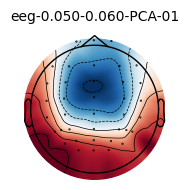

In [33]:
%matplotlib inline
mne.viz.plot_projs_topomap(projs, info=raw.info)
plt.show()


In [34]:
proj_data = projs[0]['data']['data']

In [35]:
proj_data.shape

(1, 38)

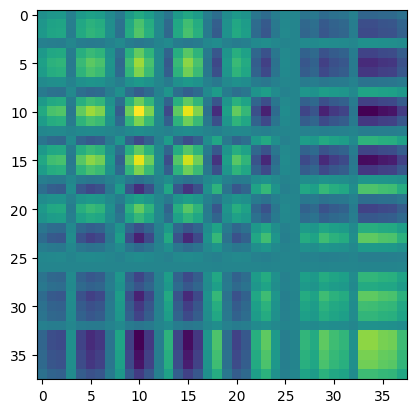

In [36]:
P = proj_data.T @ proj_data 
plt.imshow(P)

In [37]:
X_ep = epochs.get_data()
X_proj = np.array([P @ ep for ep in X_ep])


/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/2414832873.py:2: RuntimeWarning: divide by zero encountered in matmul
  X_proj = np.array([P @ ep for ep in X_ep])
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/2414832873.py:2: RuntimeWarning: overflow encountered in matmul
  X_proj = np.array([P @ ep for ep in X_ep])
/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/2414832873.py:2: RuntimeWarning: invalid value encountered in matmul
  X_proj = np.array([P @ ep for ep in X_ep])


In [38]:
epochs_proj = mne.EpochsArray(X_proj, epochs.info, tmin=epochs.tmin)

Not setting metadata
89 matching events found
No baseline correction applied
0 projection items activated


In [39]:
ev_before = epochs.average()
ev_after = epochs_proj.average()


No projector specified for this dataset. Please consider the method self.add_proj.


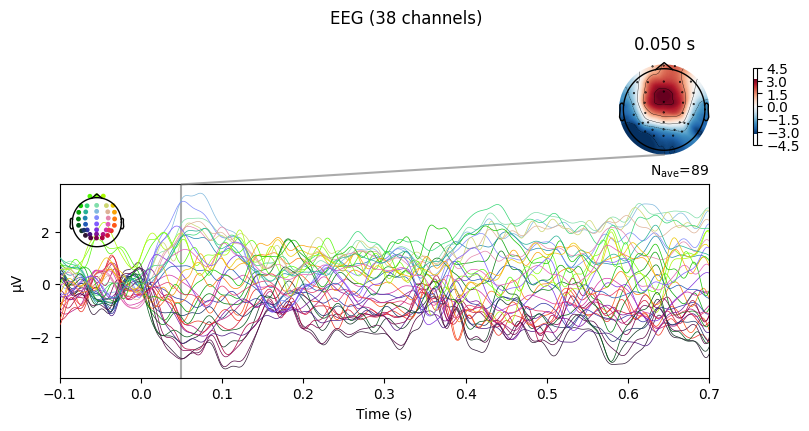

No projector specified for this dataset. Please consider the method self.add_proj.


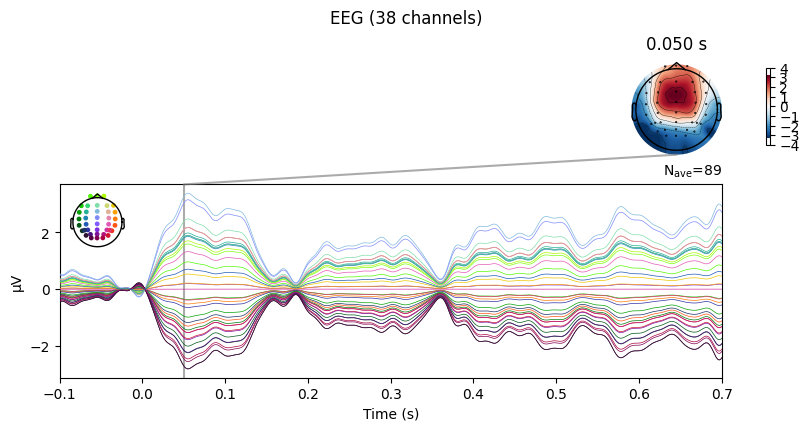

In [40]:
%matplotlib inline
ev_before.plot_joint([0.05])
ev_after.plot_joint([0.05])
plt.show()

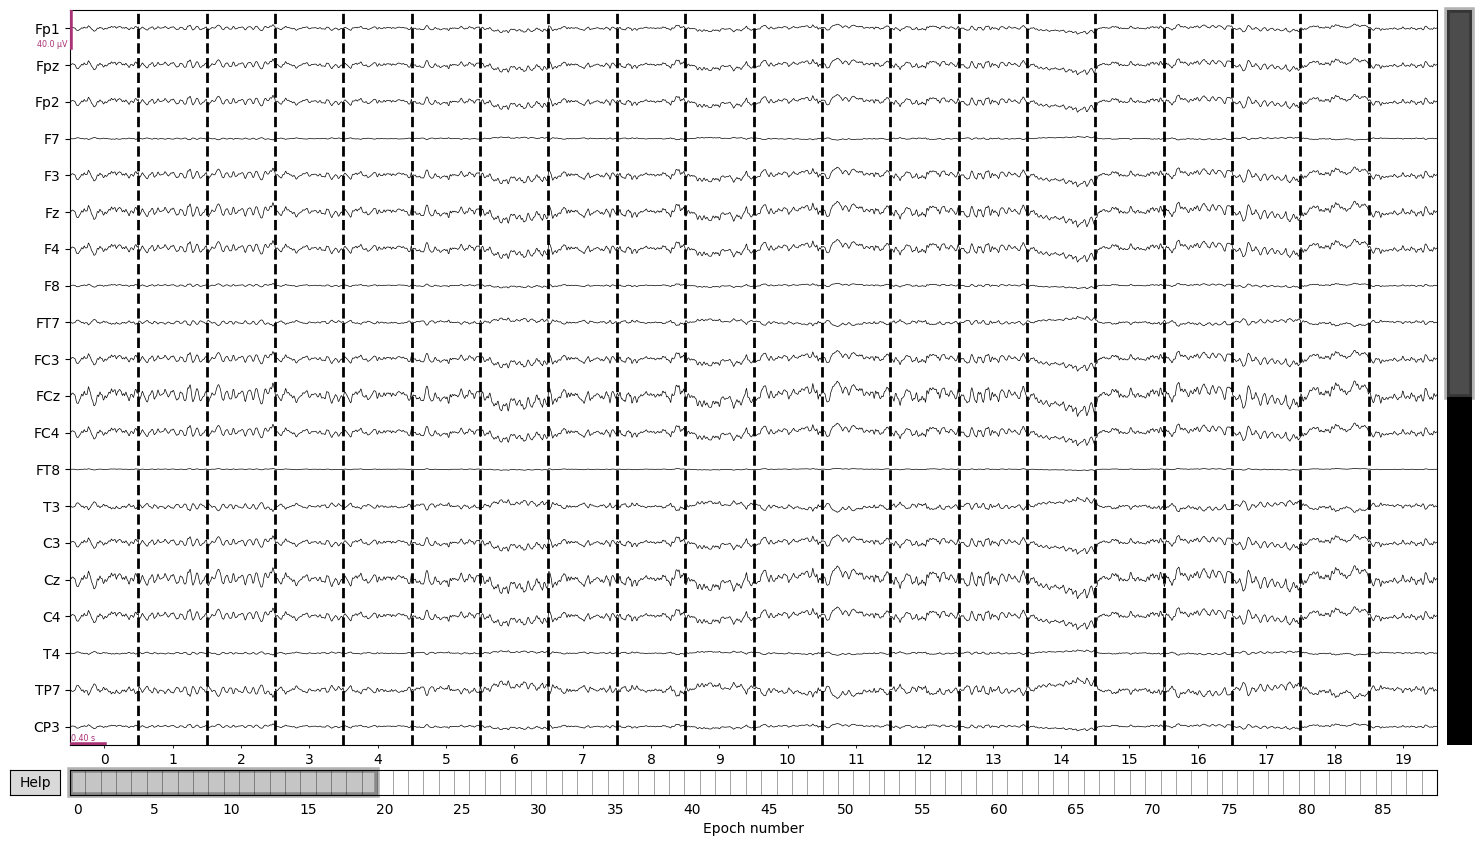

Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [ ]:
%matplotlib qt
epochs_proj.plot()

No projector specified for this dataset. Please consider the method self.add_proj.


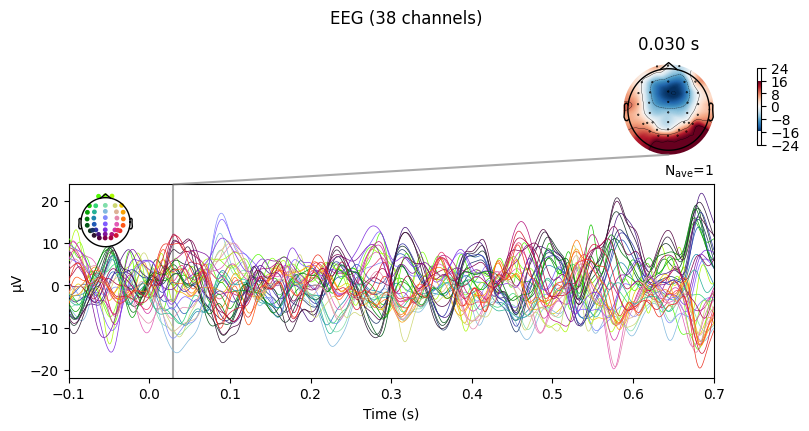

No projector specified for this dataset. Please consider the method self.add_proj.


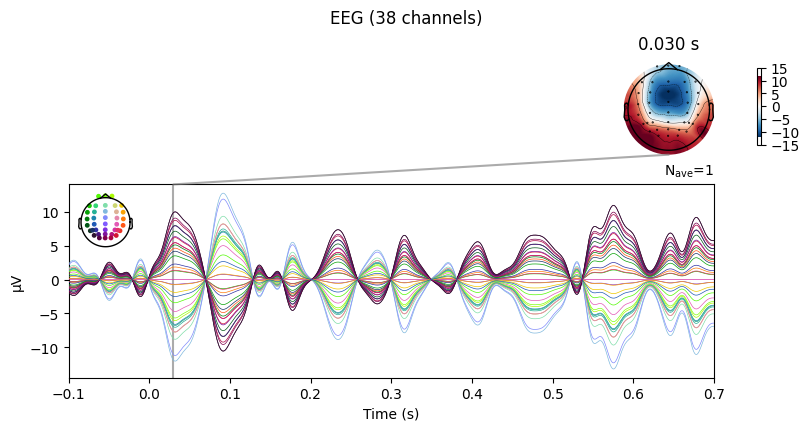

In [42]:
%matplotlib inline
epochs[17].average().plot_joint([0.03])
plt.show()
epochs_proj[17].average().plot_joint([0.03])
plt.show()


## Dangers of filtering

Setting up band-pass filter from 10 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 10.00
- Lower transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 8.75 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 1321 samples (1.321 s)

No projector specified for this dataset. Please consider the method self.add_proj.


/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/562446023.py:2: RuntimeWarning: filter_length (1321) is longer than the signal (801), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.average().filter(10,20).plot_joint([0.05])
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    0.0s finished


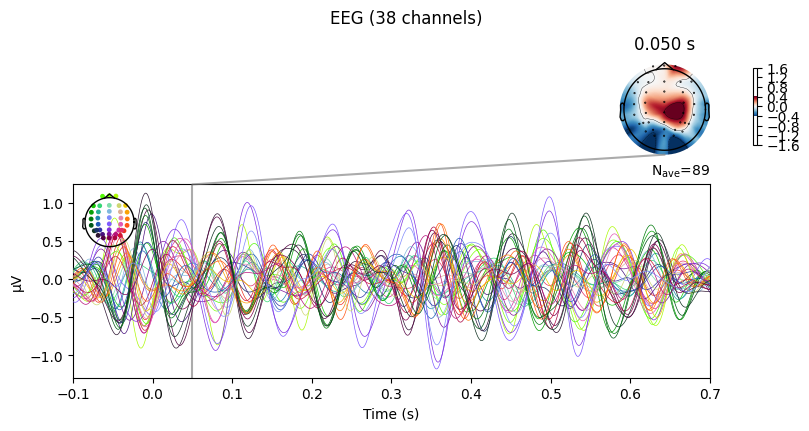

In [43]:
%matplotlib inline
epochs.average().filter(10,20).plot_joint([0.05])
plt.show()

Setting up band-pass filter from 5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 5.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (1.651 s)

No projector specified for this dataset. Please consider the method self.add_proj.


/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/1890993595.py:2: RuntimeWarning: filter_length (1651) is longer than the signal (801), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.average().filter(5,30).plot_joint([0.05])
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    0.0s finished


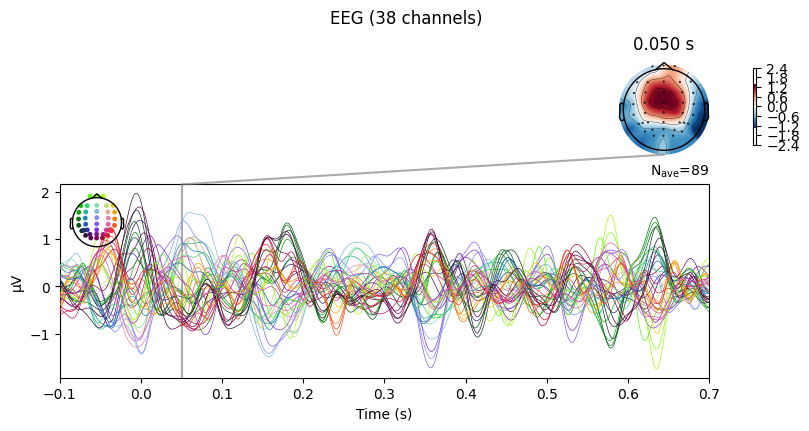

In [44]:
%matplotlib inline
epochs.average().filter(5,30).plot_joint([0.05])
plt.show()

Setting up low-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 2.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Filter length: 1651 samples (1.651 s)



/var/folders/x7/j3l1lskn5hs7tzf40r9kb7qh0000gn/T/ipykernel_29543/1781173342.py:5: RuntimeWarning: filter_length (1651) is longer than the signal (801), distortion is likely. Reduce filter length or filter a longer signal.
  filtered_signal = np.squeeze(evoked.copy().filter(0,2).pick('Cz').data)
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    0.0s finished


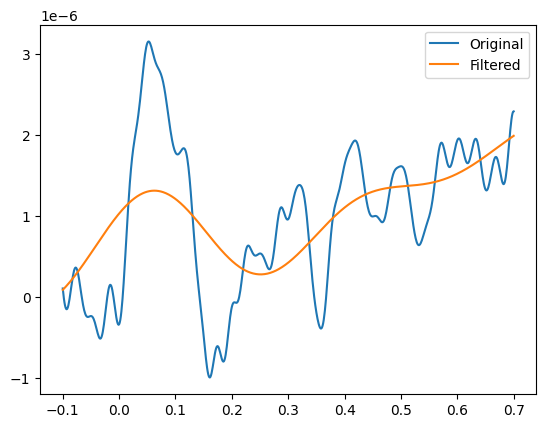

In [45]:
# take channel cz and show original signal of average evoked and filtered signal of average evoked overlayed with different cutoffs
#use matplotlib 

original_signal = np.squeeze(evoked.copy().pick('Cz').data)
filtered_signal = np.squeeze(evoked.copy().filter(0,2).pick('Cz').data)

plt.plot(epochs.times, original_signal, label='Original')
plt.plot(epochs.times, filtered_signal, label='Filtered')
plt.legend()
plt.show()


## Time-frequency analysis

No projector specified for this dataset. Please consider the method self.add_proj.


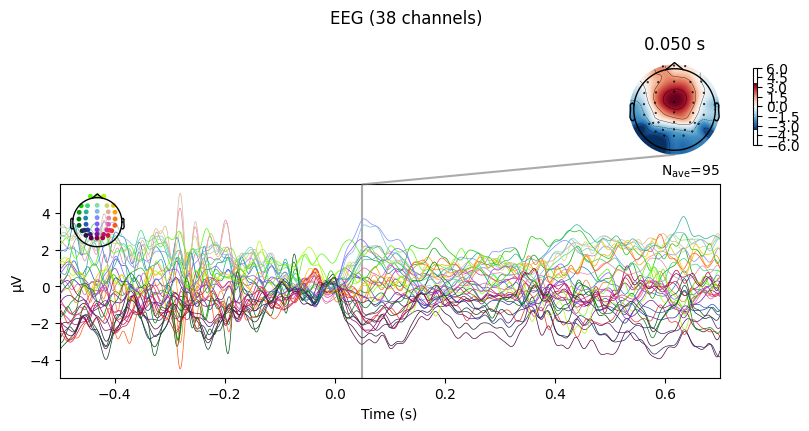

In [20]:
epochs_long.average().plot_joint([0.05])
plt.show()

In [37]:
freqs = np.logspace(*np.log10([3, 30]), num=50)
n_cycles = freqs / 2.0  
power = epochs_long.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=False,
    return_itc=False
)

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    2.8s finished


In [36]:
# power.apply_baseline((-0.5, 0), mode='zscore')

In [38]:
def log_baseline(power, baseline=(-0.5, 0.0)):
    """Log-domain baseline correction for an MNE TFR object.

    Parameters
    ----------
    power : mne.time_frequency.BaseTFR
        TFR object (e.g., EpochsTFR/AverageTFR).
    baseline : tuple[float, float]
        Baseline interval in seconds.

    Returns
    -------
    power_bc : same type as `power`
        Baseline-corrected TFR object (copy of input).
    """
    power_bc = power.copy()
    times = power_bc.times
    data = power_bc.data

    mask = (times >= baseline[0]) & (times <= baseline[1])
    if not mask.any():
        raise ValueError(
            f"Baseline {baseline} empty in [{times[0]:.3f}, {times[-1]:.3f}]"
        )

    log_pow = np.log(np.maximum(data, 1e-30))
    base_mean = log_pow[..., mask].mean(axis=-1, keepdims=True)
    power_bc.data = (log_pow - base_mean).astype(np.float32)

    return power_bc

In [39]:
power = log_baseline(power, baseline=(-0.5, 0.0))

No baseline correction applied
No baseline correction applied
No baseline correction applied


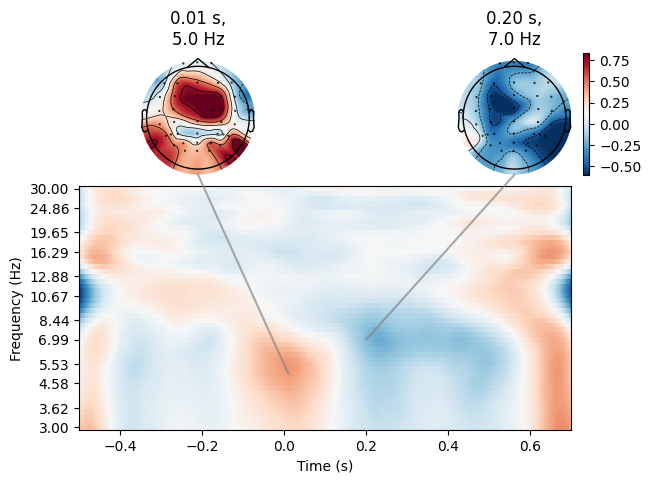

In [50]:
power.average().plot_joint(timefreqs=[(0.01,5), (0.2, 7)])
plt.show()

No baseline correction applied


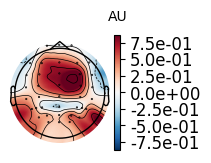

No baseline correction applied


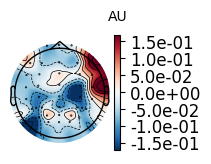

In [53]:
power.average().plot_topomap(fmin=5, fmax=7, tmin=0, tmax=0.01)
plt.show()
power.average().plot_topomap(fmin=13, fmax=25, tmin=0.2, tmax=0.21)
plt.show()


No baseline correction applied


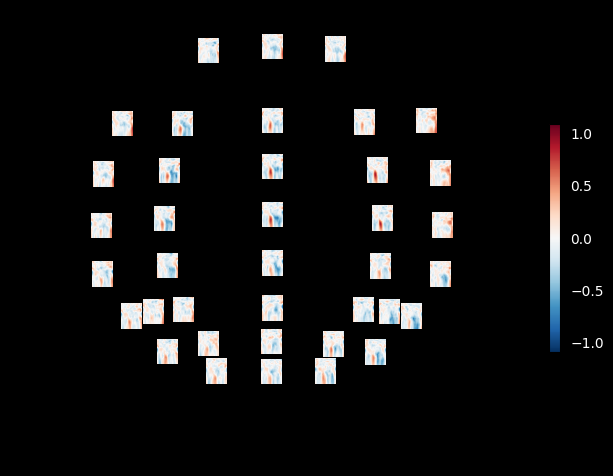

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:298: RuntimeWarning: `mask` is None, not masking the plot ...
  func(*args, **kwargs)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:298: RuntimeWarning: `mask` is None, not adding contour to the plot ...
  func(*args, **kwargs)


No baseline correction applied
No baseline correction applied
No baseline correction applied


In [55]:
%matplotlib qt
power.average().plot_topo()

In [ ]:
#now subtract evoked

**Intertrial coherence (ITC)** is a measure of how consistent oscillatory phase is across an ensemble of trials. How much do different trials resemble each other?

In [59]:
freqs = np.logspace(*np.log10([3, 30]), num=50)
n_cycles = freqs / 2.0  
_, itc = epochs_long.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=True
)

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done  38 out of  38 | elapsed:    3.9s finished


No baseline correction applied


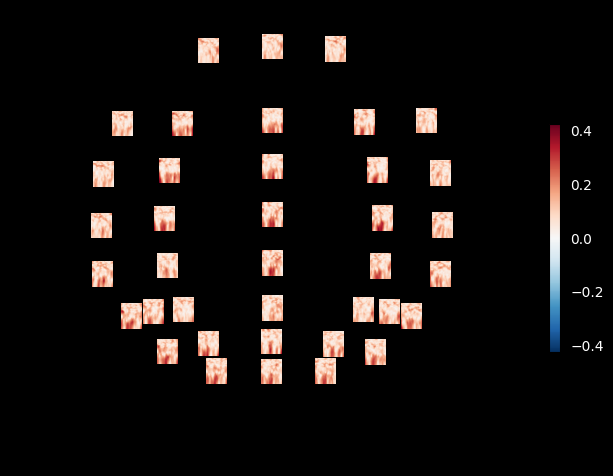

/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:298: RuntimeWarning: `mask` is None, not masking the plot ...
  func(*args, **kwargs)
/Users/dkleeva/Library/Python/3.9/lib/python/site-packages/matplotlib/cbook.py:298: RuntimeWarning: `mask` is None, not adding contour to the plot ...
  func(*args, **kwargs)


No baseline correction applied
No baseline correction applied
No baseline correction applied


In [60]:
itc.plot_topo()